# SCRIPT OPCIONES ARGENTINAS by AGUSTIN LEIVA RETAMAL

En este script veras distintos tipos de valuaciones y dashboards sobre las opciones financieras
- Como primer paso debes tener una cuenta comitente en IOL, ya que estamos utilizando su API.
- El pipeline esta hecho para analizar las opciones de GGAL, por lo que si pretender valuar otro instrumento tendras que modificar el segundo bloque. 

In [95]:
import requests

url = "https://api.invertironline.com/token"
data = {
    "username": "USUARIO",
    "password": "CONTRASEÑA",
    "grant_type": "password"
}

response = requests.post(url, data=data)
token = response.json()["access_token"]

headers = {"Authorization": f"Bearer {token}"}
print(token)


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

## 1. Conexión al Mercado y Extracción de Datos (Spot e Históricos)

Antes de realizar cualquier modelo matemático, necesitamos la "materia prima": los datos. En esta sección nos conectamos a la API del bróker para obtener dos cosas fundamentales:
1. **El precio Spot:** Es el precio actual al que cotiza la acción subyacente en este mismo momento (en nuestro caso, GGAL).
2. **Datos Históricos Ajustados:** Extraemos la serie histórica de precios diarios. Es vital que esta serie esté "ajustada" (es decir, que contemple el pago de dividendos y splits). Si no usamos precios ajustados, nuestros modelos matemáticos interpretarán una caída por pago de dividendos como un "shock" o crisis de mercado, distorsionando toda nuestra medición de riesgo.

In [72]:
# ... (tu código anterior de generación de token) ...
token = response.json()["access_token"]

# ============================================
# CONFIGURACIÓN GENERAL
# ============================================
CONFIG = {
    # Usamos la variable 'token' que acabamos de obtener
    "token": token, 
    
    "market": "bCBA",
    "symbol": "GGAL",
    "risk_free_rate": 0.45, # 45% anual
    "valuation_date": None,
    "show_columns": ["simbolo", "tipoOpcion", "fechaVencimiento",
                     "strike", "mid", "T", "iv"],
}

BASE_URL = "https://api.invertironline.com/api/v2"

# ============================================
# OBTENCIÓN DE DATOS HISTÓRICOS (IOL API)
# ============================================
import requests
from datetime import datetime, timedelta

def get_iol_historico(config, symbol=None, years=2, ajustada="ajustada"):
    """
    Obtiene la serie histórica de cotizaciones diarias desde la API de IOL.
    El parámetro 'ajustada' es vital para modelos de volatilidad (GARCH) 
    para evitar que los cortes por dividendos se lean como shocks de mercado.
    """
    sym = symbol if symbol else config["symbol"]
    market = config["market"]
    token = config["token"]
    
    # 1. Calcular rango de fechas (hoy y hace 'X' años)
    fecha_hasta = datetime.now()
    fecha_desde = fecha_hasta - timedelta(days=365 * years)
    
    # Formato requerido por IOL: YYYY-MM-DD
    str_desde = fecha_desde.strftime("%Y-%m-%d")
    str_hasta = fecha_hasta.strftime("%Y-%m-%d")
    
    # 2. Armar la URL del endpoint histórico
    # url final: /bCBA/Titulos/GGAL/Cotizacion/seriehistorica/2022-03-20/2024-03-20/ajustada
    url = f"{BASE_URL}/{market}/Titulos/{sym}/Cotizacion/seriehistorica/{str_desde}/{str_hasta}/{ajustada}"
    
    headers = {
        "Authorization": f"Bearer {token}"
    }
    
    print(f"📥 Solicitando histórico de {sym} desde {str_desde} hasta {str_hasta} ({ajustada})...")
    
    # 3. Ejecutar la petición
    response = requests.get(url, headers=headers)
    
    if response.status_code == 200:
        datos = response.json()
        print(f"✅ Se obtuvieron {len(datos)} registros históricos.")
        return datos
    else:
        print(f"❌ Error en la petición: Código {response.status_code}")
        print(response.text)
        return []

# Ejemplo de uso rápido para probar que funciona (opcional)
# datos_historicos = get_iol_historico(CONFIG, years=2)
# print(datos_historicos[-1]) # Imprime el último día para verificar

## 2. El Modelo de Black-Scholes: Calculando el Precio Teórico

El modelo de Black-Scholes es la piedra angular de las finanzas cuantitativas. Piensa en este modelo como una "calculadora teórica" que nos dice cuánto *debería* valer una opción hoy en un mundo ideal. 

Para calcular este precio "justo", la función `bs_price` toma en cuenta 5 variables clave:
* **S (Spot):** El precio actual de la acción.
* **K (Strike):** El precio al que tenemos el derecho a comprar (Call) o vender (Put).
* **T (Tiempo):** El tiempo que falta hasta que venza el contrato (anualizado).
* **r (Tasa Libre de Riesgo):** El rendimiento que obtendríamos en una inversión segura (por ejemplo, un bono del tesoro o una tasa fija).
* **Sigma ($\sigma$):** La volatilidad de la acción (qué tanto fluctúa su precio).

Con esto, el modelo nos arroja una estimación matemática para saber si las opciones en el mercado están "caras" o "baratas" en comparación con la teoría.

In [73]:
# ============================================
# IMPORTS
# ============================================

import math
from datetime import date
import pandas as pd
import requests
import matplotlib.pyplot as plt


# ============================================
# PARSER DE STRIKE DESDE DESCRIPCIÓN
# ============================================

def parse_strike(desc: str):
    """
    Extrae strike desde la descripción de IOL.
    Ej: 'Call GGAL 2,654.90 Vencimiento: 19/12/2025' -> 2654.90
    """
    import re
    if not isinstance(desc, str):
        return None

    match = re.search(r"GGAL\s+([0-9.,]+)", desc)
    if not match:
        return None

    raw = match.group(1)        # Ej: '2,654.90'
    raw = raw.replace(",", "")  # -> '2654.90'

    try:
        return float(raw)
    except ValueError:
        return None


# ============================================
# IOL: FUNCIONES DE CONEXIÓN
# ============================================

def get_iol_spot(config):
    headers = {"Authorization": f"Bearer {config['token']}"}
    url = f"{BASE_URL}/{config['market']}/Titulos/{config['symbol']}/Cotizacion"
    r = requests.get(url, headers=headers)
    r.raise_for_status()
    return r.json()["ultimoPrecio"]


def get_iol_options_chain(config):
    headers = {"Authorization": f"Bearer {config['token']}"}
    url = f"{BASE_URL}/{config['market']}/Titulos/{config['symbol']}/Opciones"

    r = requests.get(url, headers=headers)
    r.raise_for_status()
    data = r.json()

    if isinstance(data, list):
        return pd.DataFrame(data)

    # Por si viene como {"opciones": [...]} u otras variantes
    for key, value in data.items():
        if isinstance(value, list):
            return pd.DataFrame(value)

    raise ValueError(f"Estructura inesperada de respuesta: {data}")


In [89]:
# ============================================
# BLACK–SCHOLES & VOL IMPLÍCITA
# ============================================

def _norm_cdf(x: float) -> float:
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))


def bs_price(S, K, T, r, sigma, option_type):
    """
    Precio Black–Scholes sin dividendos.
    """
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return 0.0

    d1 = (math.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)

    if option_type.lower() == "call":
        return S * _norm_cdf(d1) - K * math.exp(-r * T) * _norm_cdf(d2)
    else:
        return K * math.exp(-r * T) * _norm_cdf(-d2) - S * _norm_cdf(-d1)


def implied_vol(price, S, K, T, r, option_type, tol=1e-4, max_iter=60):
    """
    IV vía bisección. Devuelve None si no converge o inputs no válidos.
    """
    if price <= 0 or S <= 0 or K <= 0 or T <= 0:
        return None

    low, high = 0.01, 5.0

    # chequeo muy básico; si con vol mínima ya da precio > mercado, no tiene solución
    if bs_price(S, K, T, r, low, option_type) > price:
        return None

    for _ in range(max_iter):
        mid = (low + high) / 2
        price_mid = bs_price(S, K, T, r, mid, option_type)

        if abs(price_mid - price) < tol:
            return mid

        if price_mid > price:
            high = mid
        else:
            low = mid

    return (low + high) / 2



In [74]:
# ------------------------------------------------------
# 1. Obtención y limpieza de datos históricos (IOL)
# ------------------------------------------------------
print("📊 Procesando datos históricos de la API local para calibrar modelo GARCH...")

# Llamamos a la nueva función
datos_json = get_iol_historico(CONFIG, years=2)

# Convertimos a DataFrame de Pandas
df_hist = pd.DataFrame(datos_json)

# Verificamos qué columnas devolvió realmente la API
print("🔍 Columnas detectadas por IOL:", df_hist.columns.tolist())

# Detección dinámica de columnas (Serie Histórica vs Cotización Diaria)
col_fecha = 'fecha' if 'fecha' in df_hist.columns else 'fechaHora'
col_precio = 'cierre' if 'cierre' in df_hist.columns else 'ultimoPrecio'

# Convertir la columna de fecha a formato datetime (soportando formatos mixtos)
df_hist[col_fecha] = pd.to_datetime(df_hist[col_fecha], format='mixed')

# (Opcional pero recomendado para datos diarios): 
# Normalizar para quedarnos solo con la fecha (sin la hora), 
# ya que al modelo GARCH solo le interesan los cierres diarios
df_hist[col_fecha] = df_hist[col_fecha].dt.normalize()

df_hist = df_hist.sort_values(col_fecha).reset_index(drop=True)
df_hist.set_index(col_fecha, inplace=True)

# Calcular retornos logarítmicos diarios usando la columna detectada
# Multiplicamos por 100 para el optimizador GARCH
df_hist['Returns'] = 100 * np.log(df_hist[col_precio] / df_hist[col_precio].shift(1))
returns = df_hist['Returns'].dropna()

print(f"✅ Se cargaron {len(returns)} ruedas históricas de GGAL y se calcularon los retornos.")

📊 Procesando datos históricos de la API local para calibrar modelo GARCH...
📥 Solicitando histórico de GGAL desde 2024-03-26 hasta 2026-03-26 (ajustada)...
✅ Se obtuvieron 487 registros históricos.
🔍 Columnas detectadas por IOL: ['ultimoPrecio', 'variacion', 'apertura', 'maximo', 'minimo', 'fechaHora', 'tendencia', 'cierreAnterior', 'montoOperado', 'volumenNominal', 'precioPromedio', 'moneda', 'precioAjuste', 'interesesAbiertos', 'puntas', 'cantidadOperaciones', 'descripcionTitulo', 'plazo', 'laminaMinima', 'lote']
✅ Se cargaron 486 ruedas históricas de GGAL y se calcularon los retornos.


### 3. La Sonrisa de la Volatilidad (Volatility Smile)

La teoría clásica de Black-Scholes asume que la volatilidad es constante para todos los precios de ejercicio (Strikes). Sin embargo, la realidad es distinta.

En este gráfico ploteamos la **Volatilidad Implícita (eje Y)** contra los diferentes **Strikes (eje X)** de un mismo vencimiento. Lo que solemos observar es una curva en forma de "U" o sonrisa. ¿Por qué ocurre esto?
* Las opciones muy *fuera del dinero (Out-of-the-Money)* suelen tener una volatilidad implícita más alta porque los inversores pagan un sobreprecio para protegerse contra movimientos extremos del mercado (cisnes negros).
* Analizar esta "sonrisa" nos permite identificar dónde está el consenso del mercado, qué contratos tienen mayor liquidez y si existe un sesgo (miedo a una caída fuerte vs. euforia por una subida).

Spot GGAL: 6430.0
Opciones obtenidas: 120
      simbolo tipoOpcion fechaVencimiento  strike       mid         T  \
0  GFGC43747A       Call       2026-04-17  4374.7  2125.070  0.060274   
1  GFGV43747A        Put       2026-04-17  4374.7     4.205  0.060274   
2  GFGC45747A       Call       2026-04-17  4574.7  1928.010  0.060274   
3  GFGV45747A        Put       2026-04-17  4574.7     5.000  0.060274   
4  GFGV47747A        Put       2026-04-17  4774.7     6.725  0.060274   

         iv  
0       NaN  
1  0.750184  
2       NaN  
3  0.693745  
4  0.650063  

Generando gráfico para el vencimiento: 2026-04-17


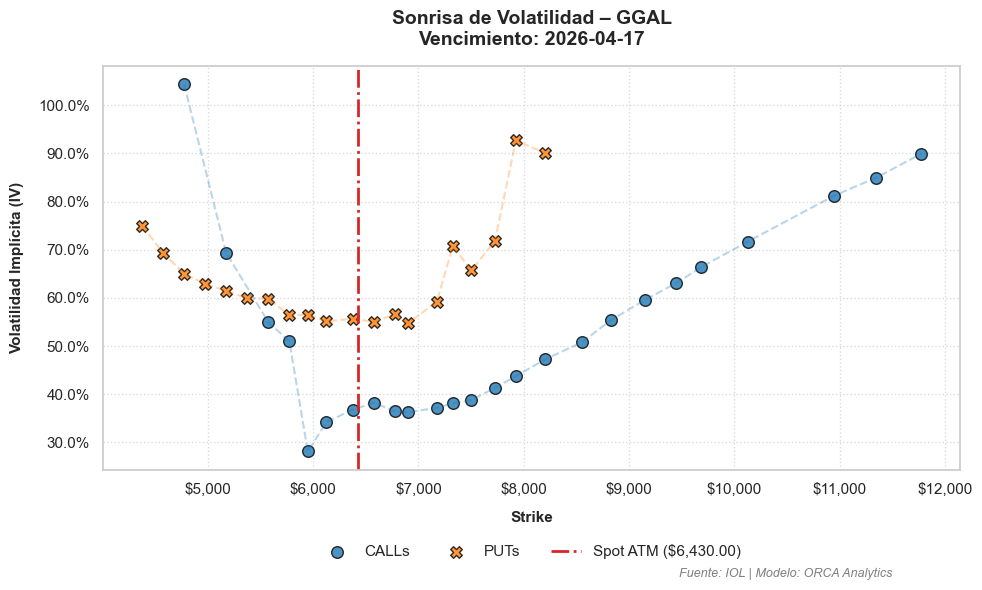

In [75]:
import pandas as pd
from datetime import date
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# ============================================
# PREPARAR EL DATAFRAME PARA SONRISA
# ============================================

def prepare_options_for_smile(df_opts, spot, config):
    df = df_opts.copy()

    # Aplanar el dict 'cotizacion'
    cot_cols = df["cotizacion"].apply(pd.Series)
    df = pd.concat([df.drop(columns=["cotizacion"]), cot_cols], axis=1)

    # Fecha de valuación
    valuation_date = config.get("valuation_date") or date.today()

    # Fecha de vencimiento y T en años
    df["fechaVencimiento"] = pd.to_datetime(df["fechaVencimiento"]).dt.date
    df["T"] = (df["fechaVencimiento"] - valuation_date).apply(
        lambda d: d.days / 365.0
    )

    # Strike desde descripción (requiere tu función parse_strike)
    df["strike"] = df["descripcion"].apply(parse_strike)

    # Precio MID
    if "precioCompra" in df.columns and "precioVenta" in df.columns:
        df["mid"] = df[["precioCompra", "precioVenta"]].mean(axis=1, skipna=True)
    else:
        df["mid"] = df["ultimoPrecio"]

    df["mid"] = df["mid"].fillna(df["ultimoPrecio"])

    # Calcular IV
    ivs = []
    rf = config["risk_free_rate"]

    for row in df.itertuples():
        opt_type = "call" if str(row.tipoOpcion).lower() == "call" else "put"
        iv = implied_vol(
            price=row.mid,
            S=spot,
            K=row.strike,
            T=row.T,
            r=rf,
            option_type=opt_type,
        )
        ivs.append(iv)

    df["iv"] = ivs

    return df


# ============================================
# GRAFICAR SONRISA DE VOLATILIDAD (PRO)
# ============================================

def plot_smile(df, vto, spot):
    # 1. Configuración de estilo institucional
    sns.set_theme(style="whitegrid", context="notebook")
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'axes.titleweight': 'bold',
        'axes.labelweight': 'bold'
    })

    df_vto = df[df["fechaVencimiento"] == vto].copy()
    
    # Filtramos opciones con IV válida y mayor a 0
    df_vto = df_vto[df_vto["iv"].notna() & (df_vto["iv"] > 0)]

    # Separar y ordenar por strike para que las líneas se dibujen bien
    calls = df_vto[df_vto["tipoOpcion"] == "Call"].sort_values("strike")
    puts = df_vto[df_vto["tipoOpcion"] == "Put"].sort_values("strike")

    fig, ax = plt.subplots(figsize=(10, 6))

    # 2. Scatter plots con mejor estética
    ax.scatter(calls["strike"], calls["iv"], 
               color='#1f77b4', s=70, alpha=0.8, label="CALLs", edgecolor='black')
    ax.scatter(puts["strike"], puts["iv"], 
               color='#ff7f0e', marker="X", s=70, alpha=0.8, label="PUTs", edgecolor='black')

    # Líneas tenues uniendo los puntos para guiar el ojo
    ax.plot(calls["strike"], calls["iv"], color='#1f77b4', linestyle='--', alpha=0.3)
    ax.plot(puts["strike"], puts["iv"], color='#ff7f0e', linestyle='--', alpha=0.3)

    # 3. Línea vertical para el precio Spot (At-The-Money)
    ax.axvline(x=spot, color='#d62728', linestyle='-.', linewidth=2, 
               label=f"Spot ATM (${spot:,.2f})")

    # 4. Formateo profesional de Ejes
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=1))
    ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

    # Etiquetas y Título
    ax.set_xlabel("Strike", fontsize=11, labelpad=10)
    ax.set_ylabel("Volatilidad Implícita (IV)", fontsize=11, labelpad=10)
    ax.set_title(f"Sonrisa de Volatilidad – GGAL\nVencimiento: {vto}", fontsize=14, pad=15)

    # 5. Leyenda limpia y reubicada
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), 
              ncol=3, frameon=False, fontsize=11)
    
    ax.grid(True, linestyle=':', alpha=0.7)

    # 6. Marca de agua (Autoridad para tu post)
    fig.text(0.90, 0.02, 'Fuente: IOL | Modelo: ORCA Analytics',
             fontsize=9, color='gray', ha='right', va='bottom', style='italic')

    # Ajustar márgenes para que no se corte la leyenda
    plt.tight_layout()
    plt.show()


# ============================================
# MAIN EXECUTION
# ============================================

if __name__ == "__main__":
    cfg = CONFIG  # Asume que tu diccionario CONFIG ya está definido arriba

    # 1) Spot
    spot = get_iol_spot(cfg)
    print("Spot GGAL:", spot)

    # 2) Cadena de opciones
    df_opts = get_iol_options_chain(cfg)
    print("Opciones obtenidas:", len(df_opts))

    # 3) Preparar IV
    df_iv = prepare_options_for_smile(df_opts, spot, cfg)
    
    # Mostrar columnas (con validación por si 'show_columns' no está en cfg)
    if "show_columns" in cfg:
        print(df_iv[cfg["show_columns"]].head())
    else:
        print(df_iv[["simbolo", "strike", "tipoOpcion", "mid", "iv"]].head())

    # 4) Graficar un vencimiento (el primero disponible)
    if not df_iv.empty:
        vto = df_iv["fechaVencimiento"].min()
        print(f"\nGenerando gráfico para el vencimiento: {vto}")
        plot_smile(df_iv, vto, spot)
    else:
        print("No se encontraron opciones para graficar.")

In [90]:
import math

def norm_pdf(x):
    return (1.0 / math.sqrt(2 * math.pi)) * math.exp(-0.5 * x * x)

def bs_greeks(S, K, T, r, sigma, option_type):
    """
    Devuelve las griegas Delta, Gamma, Vega y Theta para una opción
    usando Black–Scholes (sin dividendos).
    Si sigma es None, devuelve None en todas.
    """
    if (
        S is None or K is None or T is None or r is None or sigma is None
        or S <= 0 or K <= 0 or T <= 0 or sigma <= 0
    ):
        return {"delta": None, "gamma": None, "vega": None, "theta": None}

    option_type = option_type.lower()

    d1 = (math.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)

    pdf_d1 = norm_pdf(d1)

    # Delta
    if option_type == "call":
        delta = 0.5 * (1 + math.erf(d1 / math.sqrt(2)))
    else:
        delta = 0.5 * (math.erf(d1 / math.sqrt(2)) - 1)

    # Gamma
    gamma = pdf_d1 / (S * sigma * math.sqrt(T))

    # Vega (por punto de sigma, NO por %)
    vega = S * pdf_d1 * math.sqrt(T)

    # Theta (por año)
    if option_type == "call":
        theta = (
            - (S * pdf_d1 * sigma) / (2*math.sqrt(T))
            - r * K * math.exp(-r*T) * 0.5*(1 + math.erf(d2 / math.sqrt(2)))
        )
    else:
        theta = (
            - (S * pdf_d1 * sigma) / (2*math.sqrt(T))
            + r * K * math.exp(-r*T) * 0.5*(1 - math.erf(d2 / math.sqrt(2)))
        )

    return {
        "delta": delta,
        "gamma": gamma,
        "vega": vega,
        "theta": theta,
    }


In [91]:
# ============================
# Añadir columnas de griegas a df_iv
# ============================

df_greeks = df_iv.copy()

deltas = []
gammas = []
vegas = []
thetas = []

for row in df_greeks.itertuples():
    opt_type = "call" if row.tipoOpcion.lower() == "call" else "put"

    gre = bs_greeks(
        S = spot,
        K = row.strike,
        T = row.T,
        r = cfg["risk_free_rate"],
        sigma = row.iv,
        option_type = opt_type
    )

    deltas.append(gre["delta"])
    gammas.append(gre["gamma"])
    vegas.append(gre["vega"])
    thetas.append(gre["theta"])

df_greeks["delta"] = deltas
df_greeks["gamma"] = gammas
df_greeks["vega"]  = vegas
df_greeks["theta"] = thetas

df_greeks.head()


,simboloSubyacente,fechaVencimiento,tipoOpcion,simbolo,descripcion,pais,mercado,tipo,plazo,moneda,...,laminaMinima,lote,T,strike,mid,iv,delta,gamma,vega,theta
0,GGAL,2026-04-17,Call,GFGC43747A,"Call GGAL 4,374.70 Vencimiento: 17/04/2026",argentina,bcba,OPCIONES,t1,peso_Argentino,...,0,0,0.060274,4374.7,2125.070,NaN,NaN,NaN,NaN,NaN
1,GGAL,2026-04-17,Put,GFGV43747A,"Put GGAL 4,374.70 Vencimiento: 17/04/2026",argentina,bcba,OPCIONES,t1,peso_Argentino,...,0,0,0.060274,4374.7,4.205,0.750184,-0.009890,0.000022,41.669587,-228.805565
2,GGAL,2026-04-17,Call,GFGC45747A,"Call GGAL 4,574.70 Vencimiento: 17/04/2026",argentina,bcba,OPCIONES,t1,peso_Argentino,...,0,0,0.060274,4574.7,1928.010,NaN,NaN,NaN,NaN,NaN
3,GGAL,2026-04-17,Put,GFGV45747A,"Put GGAL 4,574.70 Vencimiento: 17/04/2026",argentina,bcba,OPCIONES,t1,peso_Argentino,...,0,0,0.060274,4574.7,5.000,0.693745,-0.012442,0.000029,50.875817,-254.535956
4,GGAL,2026-04-17,Put,GFGV47747A,"Put GGAL 4,774.70 Vencimiento: 17/04/2026",argentina,bcba,OPCIONES,t1,peso_Argentino,...,0,0,0.060274,4774.7,6.725,0.650063,-0.017226,0.000042,67.310269,-310.104872


## 4. Panel de Control (Dashboard): Griegas y Volatilidad

Para entender realmente qué está pasando con las opciones, no basta con ver una tabla llena de números; es mucho mejor verlo gráficamente. Este bloque de código genera un panel visual con 4 gráficos clave para resumir el riesgo de los contratos.

Separamos las opciones de compra (Calls) y las de venta (Puts), y graficamos lo siguiente:

- **Volatilidad Implícita (IV)**: Es el "termómetro" del mercado. Este gráfico nos muestra de un vistazo si los inversores están pagando más caro por protegerse de caídas (Puts) o por apostar a fuertes subidas (Calls).
  
- **Delta ($\Delta$):** Nos dice cuánto va a cambiar el precio de nuestra opción si la acción se mueve $1. Además, se usa como un truco rápido para estimar la probabilidad de que la opción termine siendo rentable al vencimiento.

- **Gamma ($\Gamma$)**: Es el "acelerador" del riesgo. Nos advierte si nuestra exposición está a punto de cambiar muy rápido de golpe frente a pequeños movimientos en el precio de la acción.

  
-  **Vega ($\nu$):** Mide cómo le afecta a la opción un cambio en el "nerviosismo" general del mercado. Como se ve en el gráfico, las opciones que están más cerca del precio actual de la acción son las que más sufren o se benefician por estos cambios de expectativa.

Generando Dashboard para el vencimiento: 2026-04-17
Opciones con IV y griegas válidas: 45


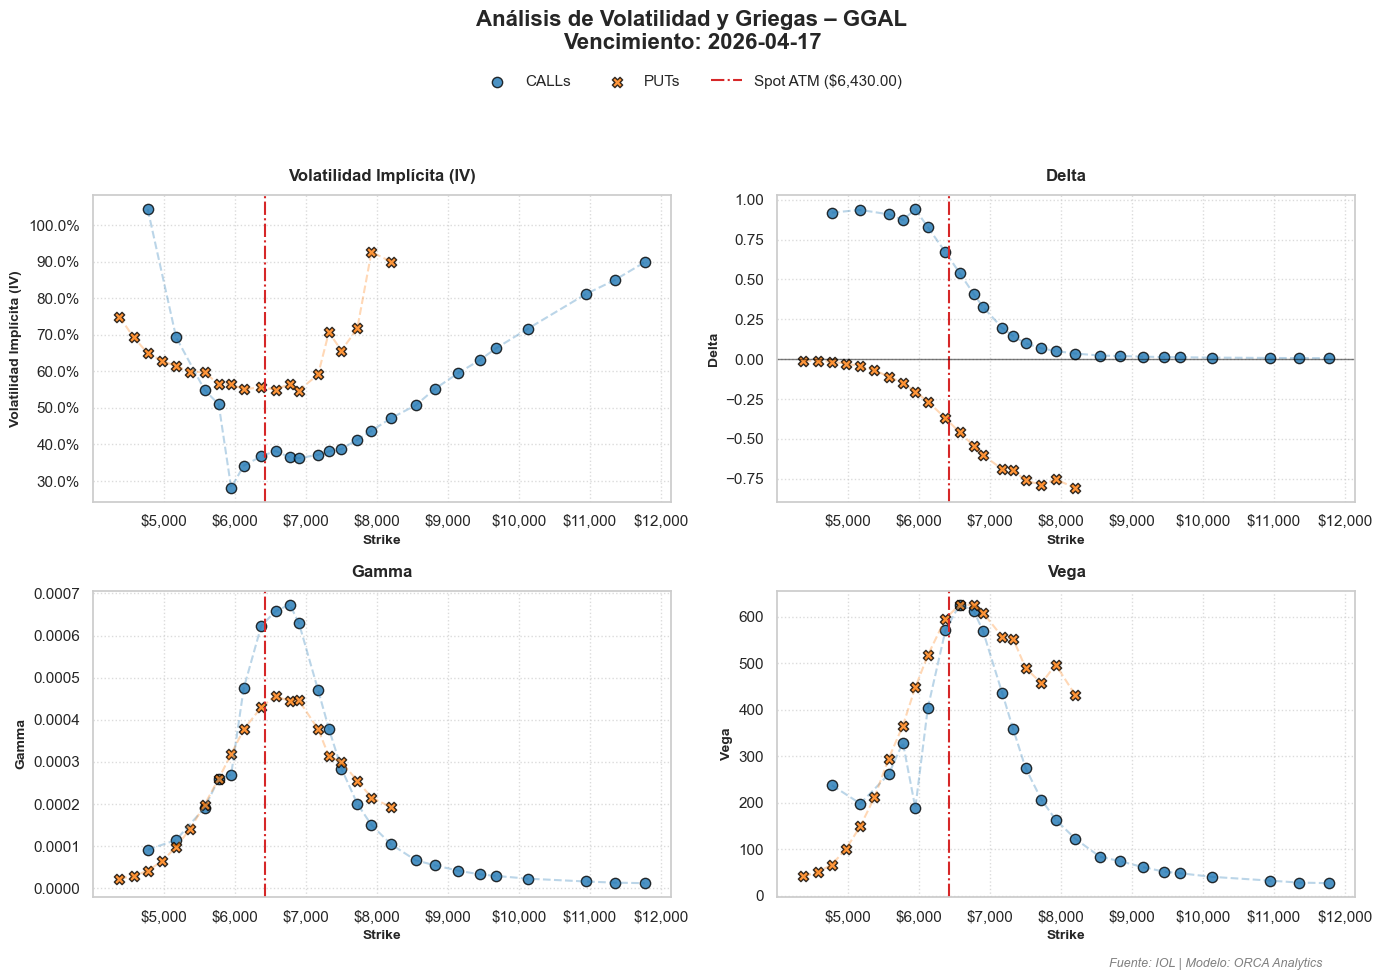

In [92]:
# ============================================
# BLOQUE DE GRÁFICOS DE GRIEGAS (DASHBOARD PRO)
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

def plot_greeks_dashboard(df_greeks, vto_target, spot):
    # 1. Configuración de estilo
    sns.set_theme(style="whitegrid", context="notebook")
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'axes.titleweight': 'bold',
        'axes.labelweight': 'bold'
    })

    print(f"Generando Dashboard para el vencimiento: {vto_target}")

    # 2. Filtrar y preparar datos
    mask = (df_greeks["fechaVencimiento"] == vto_target)
    df_vto = df_greeks[mask].copy()
    
    # Nos quedamos con opciones con IV y Delta válidas
    df_vto = df_vto.dropna(subset=["iv", "delta"])
    print(f"Opciones con IV y griegas válidas: {len(df_vto)}")

    # Separar y ordenar para que las líneas de conexión se tracen correctamente
    calls = df_vto[df_vto["tipoOpcion"] == "Call"].sort_values("strike")
    puts  = df_vto[df_vto["tipoOpcion"] == "Put"].sort_values("strike")

    # 3. Crear figura de 2x2 (Dashboard)
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"Análisis de Volatilidad y Griegas – GGAL\nVencimiento: {vto_target}", 
                 fontsize=16, fontweight='bold', y=0.98)

    # Definir qué va en cada panel: (Eje, Columna, Título, Es_Porcentaje)
    plots_info = [
        (axs[0, 0], "iv",    "Volatilidad Implícita (IV)", True),
        (axs[0, 1], "delta", "Delta", False),
        (axs[1, 0], "gamma", "Gamma", False),
        (axs[1, 1], "vega",  "Vega", False)
    ]

    # 4. Bucle para dibujar cada panel automáticamente
    for ax, col, title, is_pct in plots_info:
        # Puntos y líneas CALL
        ax.scatter(calls["strike"], calls[col], color='#1f77b4', s=55, alpha=0.8, label="CALLs", edgecolor='black')
        ax.plot(calls["strike"], calls[col], color='#1f77b4', linestyle='--', alpha=0.3)
        
        # Puntos y líneas PUT
        ax.scatter(puts["strike"], puts[col], color='#ff7f0e', marker="X", s=55, alpha=0.8, label="PUTs", edgecolor='black')
        ax.plot(puts["strike"], puts[col], color='#ff7f0e', linestyle='--', alpha=0.3)

        # Línea de Spot (Referencia ATM)
        ax.axvline(x=spot, color='#d62728', linestyle='-.', linewidth=1.5, label=f"Spot ATM (${spot:,.2f})")

        # Formato específico si es Delta (línea horizontal en el 0 para ver cuándo un Put pasa de 0 a -1)
        if col == "delta":
            ax.axhline(0, color='black', linewidth=1, linestyle='-', alpha=0.5)

        # Etiquetas y formatos
        ax.set_title(title, fontsize=12, pad=10)
        ax.set_xlabel("Strike", fontsize=10)
        ax.set_ylabel(title, fontsize=10)
        ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
        
        if is_pct:
            ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=1))
            
        ax.grid(True, linestyle=':', alpha=0.7)

    # 5. Leyenda única para todo el dashboard
    # Extraemos los labels del primer gráfico para no repetirlos 4 veces
    handles, labels = axs[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.93), 
               ncol=3, frameon=False, fontsize=11)

    # 6. Marca de agua
    fig.text(0.95, 0.02, 'Fuente: IOL | Modelo: ORCA Analytics', 
             fontsize=9, color='gray', ha='right', va='bottom', style='italic')

    # Ajustar espaciado (dejamos espacio arriba para el Suptitle y la Leyenda)
    plt.tight_layout(rect=[0, 0.03, 1, 0.90])
    plt.show()


# ============================================
# EJECUCIÓN DEL BLOQUE
# ============================================
if __name__ == "__main__":
    # Asumiendo que df_greeks y spot ya existen en tu entorno:
    vto_target = df_greeks["fechaVencimiento"].min()
    
    # Llamada a la función
    plot_greeks_dashboard(df_greeks, vto_target, spot)

## 5. Modelo Binomial y Detección de Oportunidades en BYMA

Hasta ahora usamos Black-Scholes, que es un modelo excelente pero tiene una limitación técnica: está diseñado para opciones *Europeas* (solo se pueden ejercer en la fecha de vencimiento). Sin embargo, en el mercado argentino (BYMA), las opciones sobre acciones suelen ser **Americanas**, lo que significa que el inversor puede ejercer su derecho en cualquier momento antes de que expire el contrato.


Para valuar esto con mayor precisión, implementamos un **Árbol Binomial (Modelo CRR)**. Este algoritmo funciona así:

1. **Simulación de Caminos (El Árbol):** Proyecta múltiples escenarios futuros asumiendo que el precio de la acción solo puede subir o bajar un cierto porcentaje en cada "paso" de tiempo, hasta llegar al vencimiento.
   
2. **Inducción Hacia Atrás:** Calcula el valor de la opción desde el vencimiento hacia el presente, evaluando en cada paso si es más rentable mantener la opción o *ejercerla anticipadamente*.


3. **Detección de "Mispricing":** Una vez que tenemos el precio teórico exacto, lo cruzamos contra el precio real del mercado (Mid price). 
    * Si el mercado la vende mucho más barata que nuestro modelo: **Subvaluada (Oportunidad de compra)**.
    * Si el mercado la vende mucho más cara que nuestro modelo: **Sobrevaluada (Oportunidad de venta o lanzamiento cubierto)**.

4. **Filtro Estratégico:** No compramos cualquier cosa que esté barata. Cruzamos el nivel de "descuento" con la direccionalidad (Delta) para emitir una sugerencia automática. Por ejemplo, si un Call está muy barato y tiene un Delta alto, el sistema sugiere una compra direccional alcista. 

El resultado final es un ranking automatizado que filtra el ruido del mercado y nos entrega las mejores oportunidades matemáticas del día.

In [79]:
# ============================================
# BLOQUE · Árbol binomial + ranking de oportunidades
# ============================================

import numpy as np

def binomial_tree_price(S, K, T, r, sigma, N, option_type, american=True):
    """
    Precio de una opción mediante árbol binomial CRR.

    S : spot
    K : strike
    T : tiempo a vencimiento (años)
    r : tasa libre (anual, en decimales)
    sigma : volatilidad anual (en decimales)
    N : cantidad de pasos del árbol
    option_type : 'call' o 'put'
    american : True → ejercicio americano, False → europeo
    """
    if T <= 0 or S <= 0 or K <= 0 or sigma is None or sigma <= 0:
        return np.nan

    dt = T / N
    u = math.exp(sigma * math.sqrt(dt))
    d = 1 / u
    disc = math.exp(-r * dt)
    p = (math.exp(r * dt) - d) / (u - d)

    # Precios del subyacente en el vencimiento
    ST = np.array([S * (u**j) * (d**(N - j)) for j in range(N + 1)])

    if option_type.lower() == "call":
        payoffs = np.maximum(ST - K, 0.0)
    else:
        payoffs = np.maximum(K - ST, 0.0)

    # Backward induction
    for step in range(N - 1, -1, -1):
        ST = ST[:-1] / u  # precios un paso antes
        payoffs = disc * (p * payoffs[1:] + (1 - p) * payoffs[:-1])

        if american:
            if option_type.lower() == "call":
                intrinsic = np.maximum(ST - K, 0.0)
            else:
                intrinsic = np.maximum(K - ST, 0.0)
            payoffs = np.maximum(payoffs, intrinsic)

    return payoffs[0]


# ============================
# 1) Elegimos vencimiento a analizar
# ============================

vto_target = df_greeks["fechaVencimiento"].min()
print("Vencimiento analizado:", vto_target)

df_vto = df_greeks[
    (df_greeks["fechaVencimiento"] == vto_target)
    & df_greeks["iv"].notna()
    & df_greeks["mid"].notna()
].copy()

print("Opciones con IV y mid válidos:", len(df_vto))


# ============================
# 2) Precio binomial teórico por opción
# ============================

N_STEPS = 50  # podés subir a 100 si querés más precisión

binom_prices = []
mispricing_pct = []

for row in df_vto.itertuples():
    opt_type = "call" if row.tipoOpcion.lower() == "call" else "put"

    theo = binomial_tree_price(
        S=spot,
        K=row.strike,
        T=row.T,
        r=cfg["risk_free_rate"],
        sigma=row.iv,
        N=N_STEPS,
        option_type=opt_type,
        american=True,   # en BYMA las opciones suelen ser americanas
    )

    binom_prices.append(theo)

    if theo is None or np.isnan(theo) or theo == 0:
        mispricing_pct.append(np.nan)
    else:
        # positivo → mercado más caro que modelo
        # negativo → mercado más barato que modelo
        mispricing_pct.append((row.mid - theo) / theo)


df_vto["binom_price"]   = binom_prices
df_vto["mispricing_pct"] = mispricing_pct


# ============================
# 3) Clasificación: barata / cara / justa
# ============================

cond_list = [
    df_vto["mispricing_pct"] <= -0.30,
    (df_vto["mispricing_pct"] > -0.30) & (df_vto["mispricing_pct"] <= -0.10),
    (df_vto["mispricing_pct"] > -0.10) & (df_vto["mispricing_pct"] < 0.10),
    (df_vto["mispricing_pct"] >= 0.10) & (df_vto["mispricing_pct"] < 0.30),
    df_vto["mispricing_pct"] >= 0.30,
]

choice_list = [
    "MUY BARATA",
    "BARATA",
    "JUSTA",
    "CARA",
    "MUY CARA",
]

df_vto["valor_relativo"] = np.select(cond_list, choice_list, default="SIN_DATA")


# ============================
# 4) Sugerencia básica de uso según Delta + precio relativo
# ============================

def sugerencia(row):
    if pd.isna(row["mispricing_pct"]) or pd.isna(row["delta"]):
        return "Sin recomendación"

    tipo = row["tipoOpcion"]
    delta = row["delta"]
    valrel = row["valor_relativo"]

    # Baratas → ideas de compra
    if valrel in ["MUY BARATA", "BARATA"]:
        if tipo == "Call" and delta > 0.3:
            return "Comprar CALL (apalancamiento alcista)"
        if tipo == "Put" and delta < -0.3:
            return "Comprar PUT (cobertura / visión bajista)"
        return "Interesante para comprar (bajo modelo)"

    # Caras → evitar comprar / considerar ventas cubiertas
    if valrel in ["CARA", "MUY CARA"]:
        if tipo == "Call" and delta > 0.3:
            return "Evitar compra; posible venta CALL cubierta"
        if tipo == "Put" and delta < -0.3:
            return "Evitar compra; posible venta PUT si podés asumir entrega"
        return "Evitar compra (precio exigente)"

    # Justas
    return "Precio razonable; evaluar según view y griegas"


df_vto["sugerencia"] = df_vto.apply(sugerencia, axis=1)


# ============================
# 5) Ranking final
# ============================

cols_rank = [
    "simbolo", "tipoOpcion", "fechaVencimiento",
    "strike", "mid", "binom_price", "mispricing_pct",
    "iv", "delta", "gamma", "vega", "theta",
    "valor_relativo", "sugerencia",
]

ranking = df_vto[cols_rank].sort_values("mispricing_pct")

print("\n📊 TOP opciones más BARATAS según modelo binomial:")
display(ranking.head(10))

print("\n📊 TOP opciones más CARAS según modelo binomial:")
display(ranking.tail(10))


Vencimiento analizado: 2026-04-17
Opciones con IV y mid válidos: 45

📊 TOP opciones más BARATAS según modelo binomial:


,simbolo,tipoOpcion,fechaVencimiento,strike,mid,binom_price,mispricing_pct,iv,delta,gamma,vega,theta,valor_relativo,sugerencia
1,GFGV43747A,Put,2026-04-17,4374.7,4.205,3899.332399,-0.998922,0.750184,-0.009890,0.000022,41.669587,-228.805565,MUY BARATA,Interesante para comprar (bajo modelo)
3,GFGV45747A,Put,2026-04-17,4574.7,5.000,3996.426229,-0.998749,0.693745,-0.012442,0.000029,50.875817,-254.535956,MUY BARATA,Interesante para comprar (bajo modelo)
4,GFGV47747A,Put,2026-04-17,4774.7,6.725,4101.724379,-0.998360,0.650063,-0.017226,0.000042,67.310269,-310.104872,MUY BARATA,Interesante para comprar (bajo modelo)
7,GFGV49747A,Put,2026-04-17,4974.7,11.200,4251.550618,-0.997366,0.629353,-0.027837,0.000064,100.933516,-441.365076,MUY BARATA,Interesante para comprar (bajo modelo)
9,GFGV51747A,Put,2026-04-17,5174.7,19.020,4413.344428,-0.995690,0.614524,-0.045055,0.000098,149.779572,-624.613686,MUY BARATA,Interesante para comprar (bajo modelo)
11,GFGV53747A,Put,2026-04-17,5374.7,31.050,4572.172165,-0.993209,0.599356,-0.069942,0.000142,211.821441,-836.811703,MUY BARATA,Interesante para comprar (bajo modelo)
13,GFGV55747A,Put,2026-04-17,5574.7,53.000,4768.330887,-0.988885,0.597980,-0.109271,0.000198,295.421254,-1125.417568,MUY BARATA,Interesante para comprar (bajo modelo)
15,GFGV57747A,Put,2026-04-17,5774.7,73.110,4868.339162,-0.984983,0.564312,-0.148962,0.000261,366.365967,-1251.119985,MUY BARATA,Interesante para comprar (bajo modelo)
17,GFGV59501A,Put,2026-04-17,5950.1,110.000,5046.137680,-0.978201,0.565075,-0.204972,0.000318,448.487642,-1459.725678,MUY BARATA,Interesante para comprar (bajo modelo)
19,GFGV61262A,Put,2026-04-17,6126.2,151.000,5177.472432,-0.970835,0.551154,-0.265725,0.000377,517.781901,-1530.512966,MUY BARATA,Interesante para comprar (bajo modelo)



📊 TOP opciones más CARAS según modelo binomial:


,simbolo,tipoOpcion,fechaVencimiento,strike,mid,binom_price,mispricing_pct,iv,delta,gamma,vega,theta,valor_relativo,sugerencia
36,GFGC79262A,Call,2026-04-17,7926.2,13.999,13.372779,0.046828,0.437597,0.050392,0.000150,163.828254,-734.217015,JUSTA,Precio razonable; evaluar según view y griegas
44,GFGC91501A,Call,2026-04-17,9150.1,5.000,4.762240,0.049926,0.595717,0.015635,0.000042,61.951333,-349.138917,JUSTA,Precio razonable; evaluar según view y griegas
42,GFGC88262A,Call,2026-04-17,8826.2,5.960,5.576638,0.068744,0.553273,0.019494,0.000054,74.788859,-396.978846,JUSTA,Precio razonable; evaluar según view y griegas
46,GFGC94501A,Call,2026-04-17,9450.1,4.214,3.904190,0.079353,0.630890,0.012760,0.000033,52.000635,-307.171762,JUSTA,Precio razonable; evaluar según view y griegas
54,GFGC10950A,Call,2026-04-17,10950.0,2.970,2.736188,0.085452,0.812340,0.007474,0.000016,32.591798,-239.916467,JUSTA,Precio razonable; evaluar según view y griegas
56,GFGC11350A,Call,2026-04-17,11350.0,2.615,2.400615,0.089304,0.849820,0.006400,0.000013,28.420874,-217.699342,JUSTA,Precio razonable; evaluar según view y griegas
40,GFGC85501A,Call,2026-04-17,8550.1,6.400,5.846820,0.094612,0.507481,0.022362,0.000066,84.002583,-415.457038,JUSTA,Precio razonable; evaluar según view y griegas
58,GFGC11775A,Call,2026-04-17,11775.0,2.605,2.373605,0.097487,0.899074,0.006076,0.000012,27.143073,-218.848575,JUSTA,Precio razonable; evaluar según view y griegas
48,GFGC96801A,Call,2026-04-17,9680.1,4.042,3.650643,0.107202,0.663221,0.011772,0.000029,48.491925,-299.032201,CARA,Evitar compra (precio exigente)
50,GFGC10126A,Call,2026-04-17,10126.0,3.500,3.095033,0.130844,0.716639,0.009667,0.000023,40.846364,-269.221258,CARA,Evitar compra (precio exigente)


## 6. El "Top 10" de Oportunidades y Simulación de Escenarios

Ya calculamos el valor teórico de todas las opciones y detectamos cuáles están caras o baratas. Ahora, vamos a filtrar el ruido del mercado y enfocarnos únicamente en la acción. Este bloque hace el trabajo de un analista cuantitativo:

1. **Selección del Top 10:** El código filtra automáticamente los 5 Calls y los 5 Puts con mayor "descuento" matemático. Nos muestra una tabla limpia con las mejores oportunidades de compra.

2. **Mapa Visual de Divergencia:** Graficamos esta diferencia (Mispricing) con un código de colores. Esto nos permite ver de forma instantánea qué tan desalineado está el mercado respecto a la teoría.
 
3. **Simulación y Test de Estrés:** Tomamos la opción #1 del ranking y simulamos el futuro. ¿Qué pasa si la acción sube o baja un 20%? 
    * **Panel 1 (Comparación de Modelos):** Comparamos frente a frente cómo reacciona el precio de la opción según Black-Scholes versus el Modelo Binomial.
    * **Panel 2 (Dinámica de Riesgo):** Usando un gráfico de doble eje, vemos cómo cambian simultáneamente el Delta (exposición direccional) y Vega (sensibilidad a la volatilidad) a medida que el precio de la acción se mueve. 

Esta simulación nos permite saber no solo si una opción está barata hoy, sino cómo se va a comportar nuestro riesgo si el mercado se dispara o se desploma mañana.

🎯 Top Opciones Seleccionadas (Mayor descuento teórico):


,simbolo,tipoOpcion,strike,mid,binom_price,mispricing_pct,iv,delta,valor_relativo
0,GFGC63747A,Call,6374.700000,$358.00,$358.73,-0.20%,36.78%,0.670,JUSTA
1,GFGC51747A,Call,5174.700000,$1426.55,$1426.94,-0.03%,69.34%,0.936,JUSTA
2,GFGC55747A,Call,5574.700000,$1044.00,$1044.26,-0.02%,54.97%,0.908,JUSTA
3,GFGC65747A,Call,6574.700000,$256.10,$256.02,0.03%,38.24%,0.539,JUSTA
4,GFGC59501A,Call,5950.100000,$651.00,$650.72,0.04%,28.12%,0.940,JUSTA
5,GFGV43747A,Put,4374.700000,$4.21,$3899.33,-99.89%,75.02%,-0.010,MUY BARATA
6,GFGV45747A,Put,4574.700000,$5.00,$3996.43,-99.87%,69.37%,-0.012,MUY BARATA
7,GFGV47747A,Put,4774.700000,$6.72,$4101.72,-99.84%,65.01%,-0.017,MUY BARATA
8,GFGV49747A,Put,4974.700000,$11.20,$4251.55,-99.74%,62.94%,-0.028,MUY BARATA
9,GFGV51747A,Put,5174.700000,$19.02,$4413.34,-99.57%,61.45%,-0.045,MUY BARATA


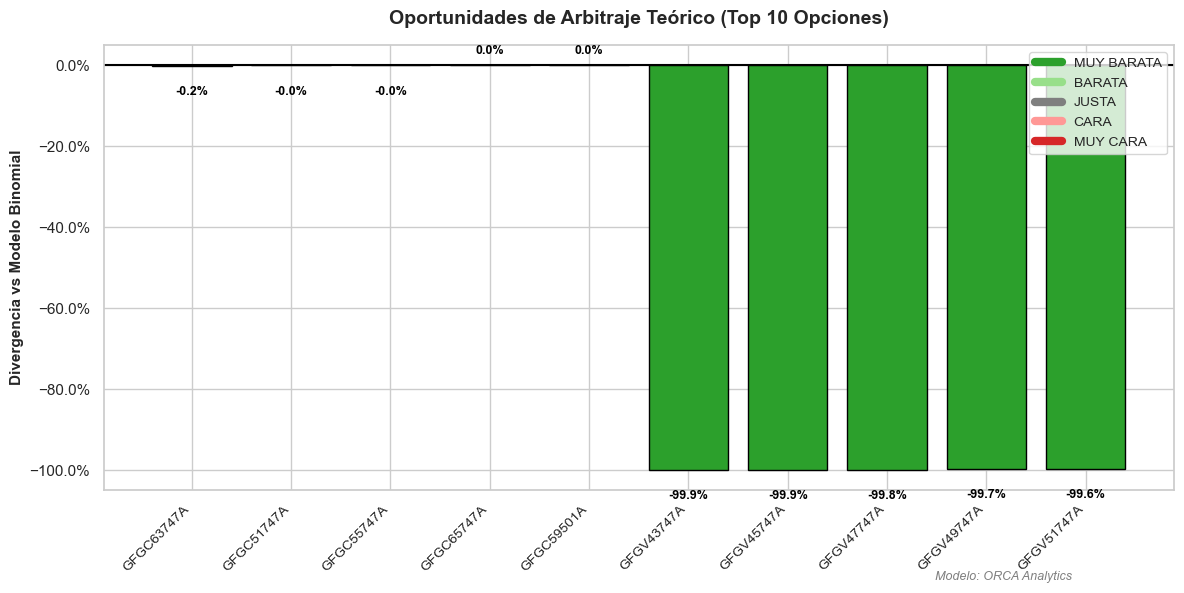

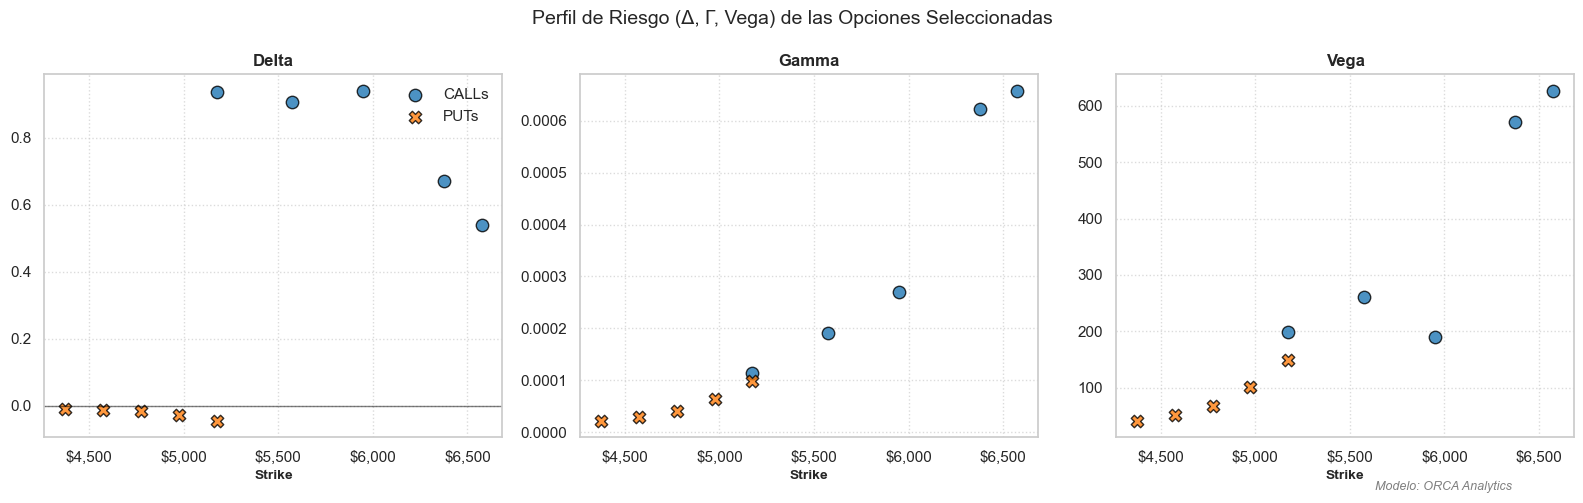


📊 Generando Simulación para la CALL más barata...


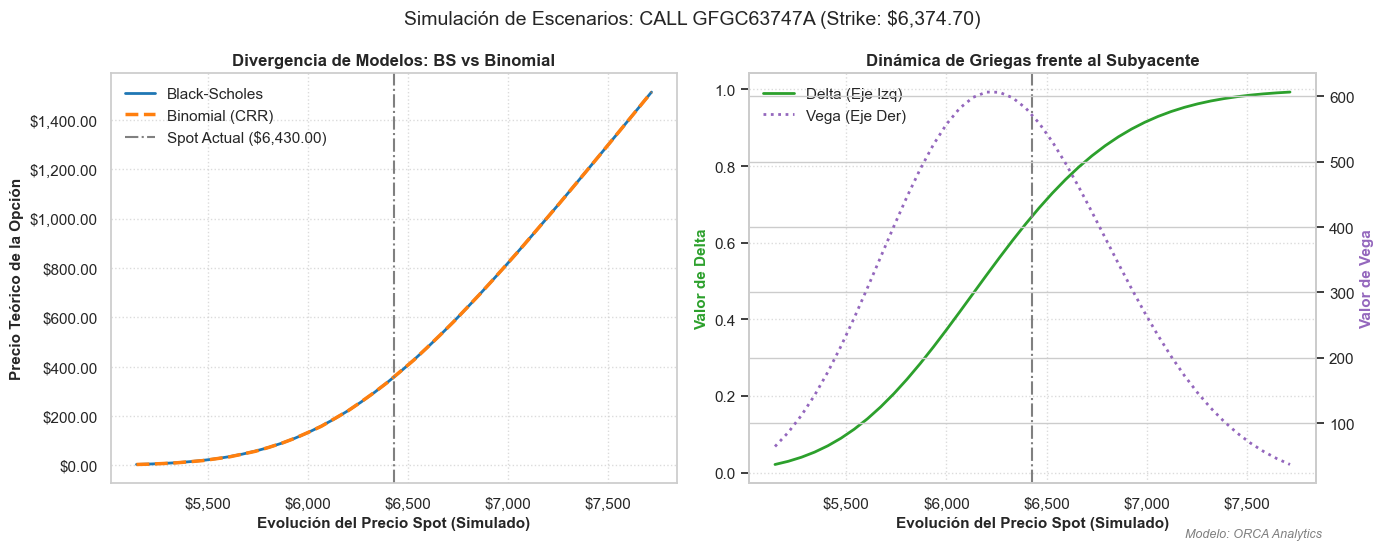


📊 Generando Simulación para la PUT más barata...


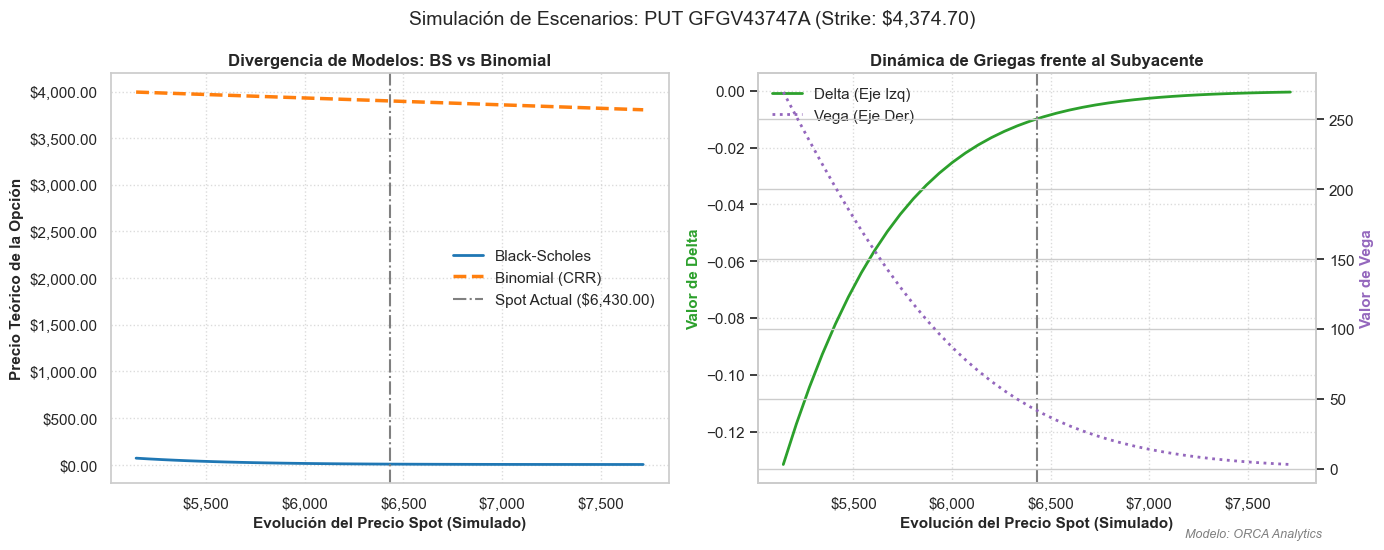

In [80]:
# ======================================================
# BLOQUE · 5 CALLs + 5 PUTs "baratas" + Simulación
# ======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D

# ------------------------------------------------------
# 1) Selección de 5 CALLs y 5 PUTs más baratas
# ------------------------------------------------------

calls_sorted = df_vto[df_vto["tipoOpcion"] == "Call"].sort_values("mispricing_pct")
puts_sorted  = df_vto[df_vto["tipoOpcion"] == "Put"].sort_values("mispricing_pct")

top_calls = calls_sorted.head(5)
top_puts  = puts_sorted.head(5)

subset = pd.concat([top_calls, top_puts]).reset_index(drop=True)

print("🎯 Top Opciones Seleccionadas (Mayor descuento teórico):")
# Formateo visual del DataFrame para el Notebook
display(
    subset[["simbolo", "tipoOpcion", "strike", "mid", "binom_price", 
            "mispricing_pct", "iv", "delta", "valor_relativo"]].style.format({
        "mid": "${:.2f}",
        "binom_price": "${:.2f}",
        "mispricing_pct": "{:.2%}",
        "iv": "{:.2%}",
        "delta": "{:.3f}"
    }).background_gradient(subset=["mispricing_pct"], cmap="RdYlGn_r")
)

# ------------------------------------------------------
# Configuración global de estilo ORCA
# ------------------------------------------------------
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold'
})

# ------------------------------------------------------
# 2) Gráfico de Mispricing Relativo (Profesional)
# ------------------------------------------------------

# Paleta de colores más institucional (Hexadecimales)
color_map = {
    "MUY BARATA": "#2ca02c",  # Verde fuerte
    "BARATA": "#98df8a",      # Verde suave
    "JUSTA": "#7f7f7f",       # Gris
    "CARA": "#ff9896",        # Rojo suave
    "MUY CARA": "#d62728",    # Rojo fuerte
}
colors = subset["valor_relativo"].map(color_map).fillna("#000000")

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(subset["simbolo"], subset["mispricing_pct"], color=colors, edgecolor='black')

ax.axhline(0, color="black", linewidth=1.5)
ax.set_ylabel("Divergencia vs Modelo Binomial", fontsize=11)
ax.set_title("Oportunidades de Arbitraje Teórico (Top 10 Opciones)", fontsize=14, pad=15)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=1))
plt.xticks(rotation=45, ha='right', fontsize=10)

# Agregar etiquetas de datos sobre cada barra
for bar in bars:
    height = bar.get_height()
    label_y = height + (0.02 if height > 0 else -0.05)
    ax.text(bar.get_x() + bar.get_width()/2., label_y,
            f'{height:.1%}', ha='center', va='bottom' if height > 0 else 'top', 
            fontsize=9, fontweight='bold', color='black')

# Leyenda personalizada
legend_elems = [Line2D([0], [0], color=c, lw=6, label=k) for k, c in color_map.items()]
ax.legend(handles=legend_elems, loc="upper right", frameon=True, fontsize=10)
fig.text(0.90, 0.02, 'Modelo: ORCA Analytics', fontsize=9, color='gray', ha='right', style='italic')

plt.tight_layout()
plt.show()

# ------------------------------------------------------
# 3) Análisis de Griegas de la Selección
# ------------------------------------------------------

calls_s = subset[subset["tipoOpcion"] == "Call"]
puts_s  = subset[subset["tipoOpcion"] == "Put"]

fig, axs = plt.subplots(1, 3, figsize=(16, 5), sharex=True)
fig.suptitle("Perfil de Riesgo (Δ, Γ, Vega) de las Opciones Seleccionadas", fontsize=14)

metrics = [("delta", "Delta", axs[0]), ("gamma", "Gamma", axs[1]), ("vega", "Vega", axs[2])]

for col, title, ax in metrics:
    ax.scatter(calls_s["strike"], calls_s[col], color='#1f77b4', s=80, alpha=0.8, label="CALLs", edgecolor='black')
    ax.scatter(puts_s["strike"], puts_s[col], color='#ff7f0e', marker="X", s=80, alpha=0.8, label="PUTs", edgecolor='black')
    
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Strike", fontsize=10)
    ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
    if col == "delta":
        ax.axhline(0, color='black', linewidth=1, linestyle='-', alpha=0.5)
    ax.grid(True, linestyle=':', alpha=0.7)

axs[0].legend(loc='best', frameon=False)
fig.text(0.95, 0.02, 'Modelo: ORCA Analytics', fontsize=9, color='gray', ha='right', style='italic')
plt.tight_layout()
plt.show()

# ------------------------------------------------------
# 4) Simulación de Escenarios y Divergencia de Modelos
# ------------------------------------------------------

call_ref = top_calls.iloc[0]
put_ref  = top_puts.iloc[0]

S_range = np.linspace(0.8 * spot, 1.2 * spot, 40)
N_STEPS = 50

# (Mantén tu función sim_price_and_greeks exacta aquí)
# def sim_price_and_greeks(row, opt_label): ...
sim_call = sim_price_and_greeks(call_ref, "CALL")
sim_put  = sim_price_and_greeks(put_ref, "PUT")

def plot_simulation(sim_data, row_ref, spot_actual):
    fig, axs = plt.subplots(1, 2, figsize=(14, 5.5))
    tipo = "CALL" if str(row_ref['tipoOpcion']).lower() == "call" else "PUT"
    fig.suptitle(f"Simulación de Escenarios: {tipo} {row_ref['simbolo']} (Strike: ${row_ref['strike']:,.2f})", fontsize=14)

    # Panel 1: Comparativa de Precios Teóricos (Evaluación de efectividad)
    axs[0].plot(S_range, sim_data["bs"], label="Black-Scholes", color="#1f77b4", linewidth=2)
    axs[0].plot(S_range, sim_data["bin"], label="Binomial (CRR)", color="#ff7f0e", linestyle="--", linewidth=2.5)
    axs[0].axvline(spot_actual, color="gray", linestyle="-.", linewidth=1.5, label=f"Spot Actual (${spot_actual:,.2f})")
    
    axs[0].set_xlabel("Evolución del Precio Spot (Simulado)", fontsize=11)
    axs[0].set_ylabel("Precio Teórico de la Opción", fontsize=11)
    axs[0].set_title("Divergencia de Modelos: BS vs Binomial", fontsize=12)
    axs[0].legend(frameon=False)
    axs[0].grid(True, linestyle=':', alpha=0.7)
    axs[0].yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.2f}'))
    axs[0].xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

    # Panel 2: Ejes Gemelos (Twinx) para Delta y Vega
    ax1 = axs[1]
    ax2 = ax1.twinx() # <--- LA CLAVE PARA GRAFICAR DOS ESCALAS DISTINTAS

    line1 = ax1.plot(S_range, sim_data["delta"], color="#2ca02c", linewidth=2, label="Delta (Eje Izq)")
    line2 = ax2.plot(S_range, sim_data["vega"], color="#9467bd", linewidth=2, linestyle=":", label="Vega (Eje Der)")
    ax1.axvline(spot_actual, color="gray", linestyle="-.", linewidth=1.5)

    ax1.set_xlabel("Evolución del Precio Spot (Simulado)", fontsize=11)
    ax1.set_ylabel("Valor de Delta", color="#2ca02c", fontsize=11, fontweight='bold')
    ax2.set_ylabel("Valor de Vega", color="#9467bd", fontsize=11, fontweight='bold')
    ax1.set_title("Dinámica de Griegas frente al Subyacente", fontsize=12)
    
    # Unir leyendas de ambos ejes
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='best', frameon=False)
    
    ax1.grid(True, linestyle=':', alpha=0.7)
    ax1.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

    fig.text(0.95, 0.02, 'Modelo: ORCA Analytics', fontsize=9, color='gray', ha='right', style='italic')
    plt.tight_layout()
    plt.show()

print("\n📊 Generando Simulación para la CALL más barata...")
plot_simulation(sim_call, call_ref, spot)

print("\n📊 Generando Simulación para la PUT más barata...")
plot_simulation(sim_put, put_ref, spot)

## 7. Simulación Avanzada: Monte Carlo con Volatilidad Estocástica (GARCH)

El modelo anterior de simulación (GBM) es muy útil, pero tiene un punto ciego: asume que la volatilidad es un número constante y estático todos los días. Sin embargo, sabemos que el mercado real tiene "memoria". Los días de mucho pánico suelen estar seguidos de más días de pánico, un fenómeno conocido como *Clustering* o agrupamiento de volatilidad.

Para capturar esta realidad, implementamos un modelo **GARCH(1,1)** (Generalized Autoregressive Conditional Heteroskedasticity). En lugar de usar una volatilidad fija, este algoritmo permite que la volatilidad "respire" y cambie día a día en nuestra simulación.

¿Cómo funciona este bloque?

1. **Calibración Histórica:** Descargamos los últimos 2 años de historia del activo y calculamos sus retornos diarios. El algoritmo "aprende" matemáticamente cómo reacciona esta acción ante los shocks del mercado (parámetros Omega, Alpha y Beta).
   
2. **Simulación Dinámica:** Lanzamos 10,000 escenarios futuros. Si en una de las simulaciones la acción sufre una caída brusca un martes, el modelo automáticamente inyecta más volatilidad para el miércoles, simulando el nerviosismo real de los inversores.


3. **Colas Gordas (Fat Tails):** Al usar GARCH, nuestro gráfico de distribución final (Panel Derecho) captura mejor el riesgo de eventos extremos ("Cisnes Negros"). 

El resultado es un mapa de probabilidades y zonas de riesgo mucho más realista y conservador, ideal para diseñar coberturas institucionales y no ser tomados por sorpresa frente a un colapso del mercado.

📊 Procesando datos históricos de la API local para calibrar modelo GARCH...
📥 Solicitando histórico de GGAL desde 2024-03-26 hasta 2026-03-26 (ajustada)...
✅ Se obtuvieron 487 registros históricos.
✅ Se cargaron 486 ruedas históricas y se calcularon los retornos.
⚙️ Calibrando parámetros GARCH(1,1)...
📌 Parámetros GARCH -> ω: 0.000066 | α: 0.0213 | β: 0.9273


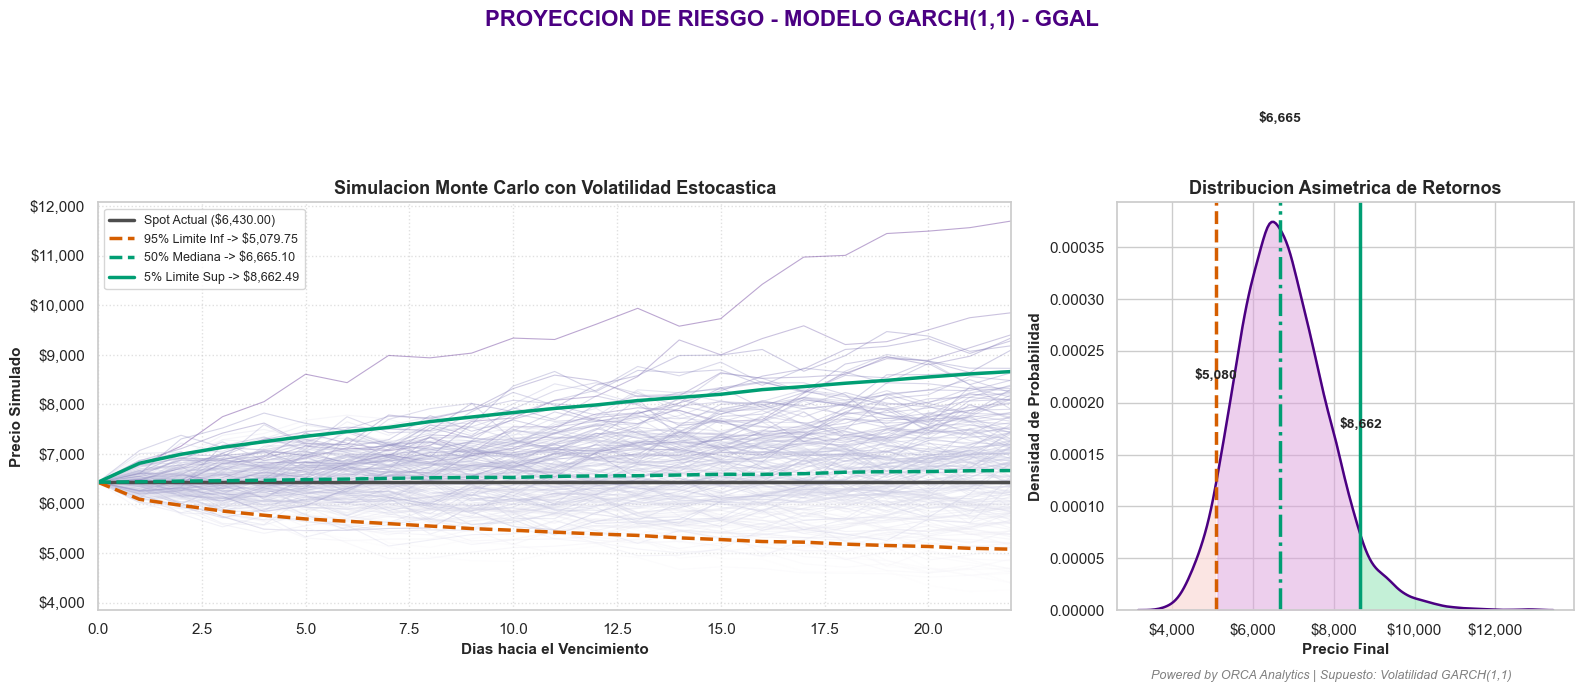


📊 Resumen Analítico de Escenarios al Vencimiento:
-> Escenario de Riesgo (5% Probabilidad):    < $5,079.75
-> Escenario Base (90% Probabilidad):       Entre $5,079.75 y $8,662.49
-> Escenario de Oportunidad (5% Probabilidad): > $8,662.49


In [82]:
# ======================================================
# BLOQUE · SIMULACIÓN MONTE CARLO CON GARCH(1,1)
# ======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from arch import arch_model
from datetime import date

# ------------------------------------------------------
# 1. Obtención y limpieza de datos históricos (IOL)
# ------------------------------------------------------
print("📊 Procesando datos históricos de la API local para calibrar modelo GARCH...")

# Obtener datos (Asegúrate de tener la función get_iol_historico definida arriba)
datos_json = get_iol_historico(CONFIG, years=2)
df_hist = pd.DataFrame(datos_json)

# Detección dinámica de columnas (Serie Histórica vs Cotización Diaria)
col_fecha = 'fecha' if 'fecha' in df_hist.columns else 'fechaHora'
col_precio = 'cierre' if 'cierre' in df_hist.columns else 'ultimoPrecio'

# Convertir fecha soportando formatos mixtos y normalizar a nivel diario
df_hist[col_fecha] = pd.to_datetime(df_hist[col_fecha], format='mixed').dt.normalize()
df_hist = df_hist.sort_values(col_fecha).reset_index(drop=True)
df_hist.set_index(col_fecha, inplace=True)

# Calcular retornos logarítmicos diarios (Multiplicado por 100 para el optimizador GARCH)
df_hist['Returns'] = 100 * np.log(df_hist[col_precio] / df_hist[col_precio].shift(1))
returns = df_hist['Returns'].dropna()

print(f"✅ Se cargaron {len(returns)} ruedas históricas y se calcularon los retornos.")

# ------------------------------------------------------
# 2. Ajuste del Modelo GARCH(1,1)
# ------------------------------------------------------
print("⚙️ Calibrando parámetros GARCH(1,1)...")

# Asumimos una media constante y una distribución normal para los residuos
am = arch_model(returns, vol='Garch', p=1, q=1, dist='Normal')
res = am.fit(disp='off')

# Extraer parámetros optimizados (ajustando la escala)
mu = res.params['mu'] / 100
omega = res.params['omega'] / 10000
alpha = res.params['alpha[1]']
beta = res.params['beta[1]']

# Última varianza condicional estimada y último shock (residuo)
last_var = res.conditional_volatility.iloc[-1]**2 / 10000
last_shock = res.resid.iloc[-1] / 100

print(f"📌 Parámetros GARCH -> ω: {omega:.6f} | α: {alpha:.4f} | β: {beta:.4f}")

# ------------------------------------------------------
# 3. Parámetros de la Opción ATM y Motor de Simulación
# ------------------------------------------------------
# Extraer días al vencimiento de la opción más cercana al Spot
df_vto_mc = df_vto.copy()
df_vto_mc['dist_spot'] = abs(df_vto_mc['strike'] - spot)
atm_idx = df_vto_mc['dist_spot'].idxmin()
atm_option = df_vto_mc.loc[atm_idx]

val_date = CONFIG.get("valuation_date") or date.today()
dias_vto = (atm_option['fechaVencimiento'] - val_date).days
if dias_vto <= 0: dias_vto = 1

N_SIMS = 10000
N_STEPS = dias_vto

# Matrices para la simulación
S = np.zeros((N_STEPS + 1, N_SIMS))
S[0] = spot

var = np.zeros((N_STEPS + 1, N_SIMS))
var[0] = last_var
shock_previo = np.full(N_SIMS, last_shock)

np.random.seed(42) # Reproducibilidad
for t in range(1, N_STEPS + 1):
    # Ecuación de Varianza GARCH(1,1)
    var[t] = omega + alpha * (shock_previo**2) + beta * var[t-1]
    
    # Shock aleatorio basado en la varianza estocástica
    Z = np.random.standard_normal(N_SIMS)
    shock_actual = np.sqrt(var[t]) * Z
    
    # Retorno y actualización de precio
    retorno_t = mu + shock_actual
    S[t] = S[t-1] * np.exp(retorno_t)
    
    shock_previo = shock_actual

precios_finales = S[-1, :]

# Percentiles
p05 = np.percentile(precios_finales, 5)
p50 = np.percentile(precios_finales, 50)
p95 = np.percentile(precios_finales, 95)

# ------------------------------------------------------
# 4. Dashboard Visual "ORCA Analytics"
# ------------------------------------------------------
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({'font.family': 'sans-serif', 'axes.titleweight': 'bold', 'axes.labelweight': 'bold'})

color_base = '#4B0082'   # Indigo para modelo GARCH
color_risk = '#D55E00'   
color_opp = '#009E73'    

fig, axs = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [2, 1]})
fig.suptitle(f"PROYECCION DE RIESGO - MODELO GARCH(1,1) - GGAL", fontsize=16, fontweight='bold', y=0.98, color=color_base)

# -- Panel Izquierdo: Spaghetti Plot --
muestra = 200
final_sub = S[-1, :muestra]
norm = plt.Normalize(final_sub.min(), final_sub.max())
cmap = plt.colormaps['Purples'] 

for i in range(muestra):
    axs[0].plot(S[:, i], alpha=0.35, color=cmap(norm(S[-1, i])), linewidth=0.8) 

axs[0].axhline(spot, color='#4D4D4D', linestyle='-', linewidth=2.5, label=f"Spot Actual (${spot:,.2f})")

time_axis = np.arange(N_STEPS + 1)
pct_time = np.percentile(S, [5, 50, 95], axis=1)

axs[0].plot(time_axis, pct_time[0, :], color=color_risk, linestyle='--', linewidth=2.5, label=f"95% Limite Inf -> ${p05:,.2f}")
axs[0].plot(time_axis, pct_time[1, :], color=color_opp, linestyle='--', linewidth=2.5, label=f"50% Mediana -> ${p50:,.2f}")
axs[0].plot(time_axis, pct_time[2, :], color=color_opp, linestyle='-', linewidth=2.5, label=f"5% Limite Sup -> ${p95:,.2f}")

axs[0].set_title(f"Simulacion Monte Carlo con Volatilidad Estocastica", fontsize=13)
axs[0].set_xlabel("Dias hacia el Vencimiento", fontsize=11)
axs[0].set_ylabel("Precio Simulado", fontsize=11)
axs[0].set_xlim(0, N_STEPS)
axs[0].yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
axs[0].legend(loc="upper left", frameon=True, fontsize=9)
axs[0].grid(True, linestyle=':', alpha=0.6)

# -- Panel Derecho: Densidad --
sns.kdeplot(precios_finales, ax=axs[1], color=color_base, linewidth=1.8)
dx, dy = sns.kdeplot(precios_finales, ax=axs[1], color=color_base, alpha=0).get_lines()[0].get_data()

axs[1].fill_between(dx, dy, where=(dx <= p05), color='#FADBD8', alpha=0.7)
axs[1].fill_between(dx, dy, where=(dx >= p05) & (dx <= p95), color='#DDA0DD', alpha=0.5)
axs[1].fill_between(dx, dy, where=(dx >= p95), color='#ABEBC6', alpha=0.7)

axs[1].axvline(p05, color=color_risk, linestyle='--', linewidth=2.5)
axs[1].axvline(p50, color=color_opp, linestyle='-.', linewidth=2.5)
axs[1].axvline(p95, color=color_opp, linestyle='-', linewidth=2.5)

for p_val in [p05, p50, p95]:
    d_val = np.interp(p_val, dx, dy)
    axs[1].text(p_val, d_val + 0.0001, f'${p_val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

axs[1].set_title("Distribucion Asimetrica de Retornos", fontsize=13)
axs[1].set_xlabel("Precio Final", fontsize=11)
axs[1].set_ylabel("Densidad de Probabilidad", fontsize=11)
axs[1].xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

fig.text(0.95, 0.02, 'Powered by ORCA Analytics | Supuesto: Volatilidad GARCH(1,1)', fontsize=9, color='gray', ha='right', va='bottom', style='italic')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n📊 Resumen Analítico de Escenarios al Vencimiento:")
print(f"-> Escenario de Riesgo (5% Probabilidad):    < ${p05:,.2f}")
print(f"-> Escenario Base (90% Probabilidad):       Entre ${p05:,.2f} y ${p95:,.2f}")
print(f"-> Escenario de Oportunidad (5% Probabilidad): > ${p95:,.2f}")

## 8. Asignación de Capital: Probabilidad de Éxito (POP) y Valor Esperado (EV)

Hasta aquí, identificamos opciones "baratas" (Modelo Binomial) y proyectamos hacia dónde puede ir el mercado (Simulación GARCH). Sin embargo, a la hora de poner dinero real, necesitamos responder a dos preguntas críticas que se hace cualquier mesa de dinero: **¿Qué probabilidad tengo de ganar?** y **¿Cuánto espero ganar en promedio?**

Este bloque toma nuestras 10 mejores oportunidades y las cruza contra los miles de escenarios generados por Monte Carlo para calcular las métricas definitivas del trading cuantitativo:

1. **Punto de Empate (Break-Even):** Para ganar dinero comprando una opción, no basta con que la acción suba (Call) o baje (Put). Tiene que moverse lo suficiente como para *cubrir el costo (prima)* que pagamos por entrar al trade.

2. **Probabilidad de Éxito (POP - Probability of Profit):** Es exactamente el porcentaje de nuestros escenarios simulados donde la operación termina con ganancia neta. Si el POP es del 65%, significa que en 65 de cada 100 universos paralelos, este trade es ganador.

 
3. **Valor Esperado (EV - Expected Value):** Es el promedio matemático de nuestras ganancias y pérdidas. Si repetimos esta misma operación miles de veces, ¿ganamos o perdemos dinero a largo plazo? Un EV positivo es el "Santo Grial" del trading algorítmico.


4. **Retorno Esperado (ROI):** Convierte el Valor Esperado en un porcentaje sobre nuestra inversión inicial para comparar fácilmente entre distintos contratos.

**¿Por qué es vital este dashboard?** A veces el Modelo Binomial nos dice que una opción muy lejana (Out-of-the-Money) está "regalada". Pero al pasarla por este filtro, vemos que su Probabilidad de Éxito (POP) es apenas del 5%. Con este panel visual, filtramos las trampas del mercado y solo asignamos capital a operaciones con un balance óptimo entre riesgo y recompensa matemática.

🧠 Calculando Probabilidad de Ganancia (POP) y Valor Esperado (EV)...

🎯 Ranking de Opciones por Probabilidad de Éxito (POP):


,Simbolo,Tipo,Strike,Prima,BEP,POP,EV,ROI_Exp
1,GFGC51747A,CALL,$5174.70,$1426.55,$6601.25,52.50%,$171.94,12.05%
4,GFGC59501A,CALL,$5950.10,$651.00,$6601.10,52.50%,$281.23,43.20%
2,GFGC55747A,CALL,$5574.70,$1044.00,$6618.70,51.82%,$193.30,18.52%
0,GFGC63747A,CALL,$6374.70,$358.00,$6732.70,47.50%,$282.66,78.96%
3,GFGC65747A,CALL,$6574.70,$256.10,$6830.80,44.12%,$270.33,105.56%
9,GFGV51747A,PUT,$5174.70,$19.02,$5155.68,5.95%,$3.88,20.40%
8,GFGV49747A,PUT,$4974.70,$11.20,$4963.50,3.86%,$1.66,14.85%
7,GFGV47747A,PUT,$4774.70,$6.72,$4767.97,2.31%,$-0.17,-2.50%
6,GFGV45747A,PUT,$4574.70,$5.00,$4569.70,1.28%,$-2.04,-40.80%
5,GFGV43747A,PUT,$4374.70,$4.21,$4370.49,0.55%,$-3.07,-73.10%


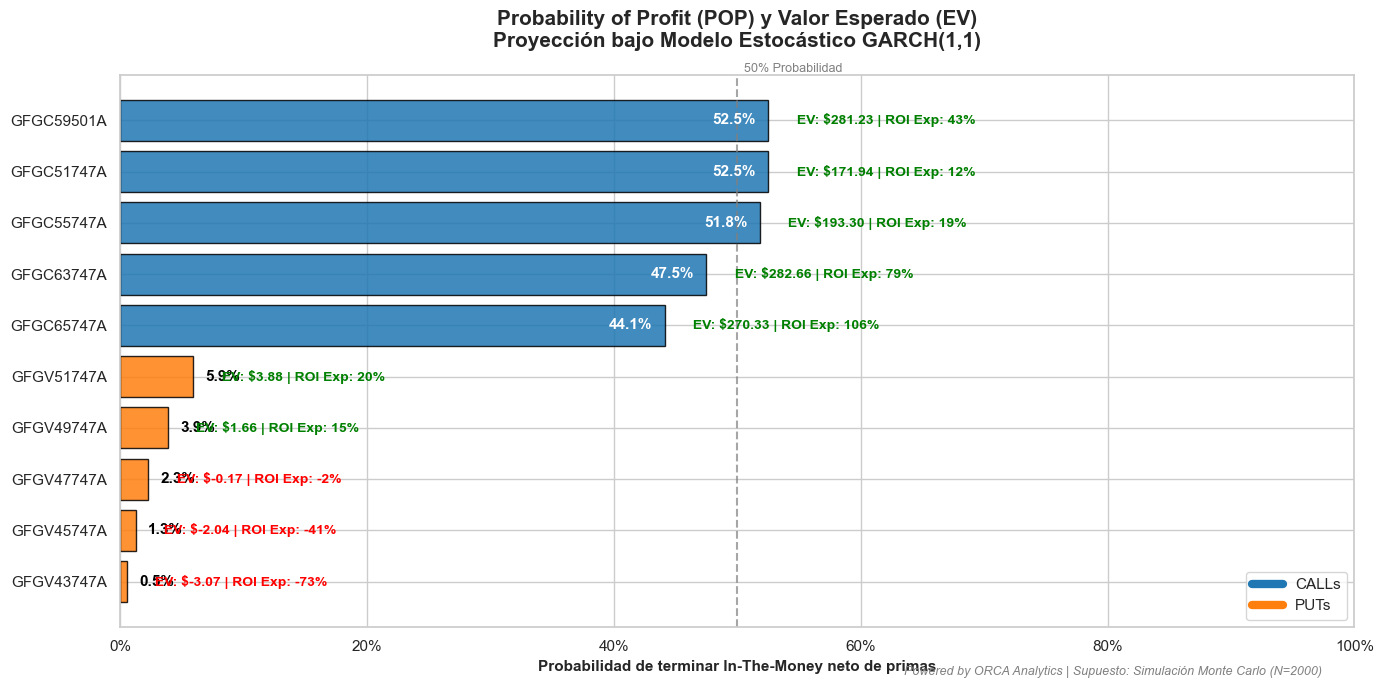

In [83]:
# ======================================================
# BLOQUE · ASIGNACIÓN DE CAPITAL: POP & EXPECTED VALUE (GARCH)
# ======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

print("🧠 Calculando Probabilidad de Ganancia (POP) y Valor Esperado (EV)...")

# Asumimos que 'subset' (tus 10 opciones seleccionadas) y 'precios_finales' (de GARCH) ya existen en memoria
resultados_estrategia = []

# Iteramos sobre las opciones seleccionadas (Top 5 Calls y Top 5 Puts)
for idx, row in subset.iterrows():
    tipo = str(row['tipoOpcion']).upper()
    strike = row['strike']
    prima_pagada = row['mid']  # Usamos el precio MID como costo de entrada
    
    if tipo == "CALL":
        # Break-Even: El precio debe superar el Strike + Prima pagada
        bep = strike + prima_pagada
        # Payoff al vencimiento para los 2000 escenarios
        payoff = np.maximum(precios_finales - strike, 0)
    else: # PUT
        # Break-Even: El precio debe caer por debajo del Strike - Prima pagada
        bep = strike - prima_pagada
        payoff = np.maximum(strike - precios_finales, 0)
        
    # PnL (Pérdidas y Ganancias) neto
    pnl_neto = payoff - prima_pagada
    
    # Métrica 1: Probabilidad de Ganancia (POP) -> % de escenarios donde PnL > 0
    pop = np.mean(pnl_neto > 0)
    
    # Métrica 2: Valor Esperado Neto (EV) -> Promedio matemático de PnL
    ev = np.mean(pnl_neto)
    
    # Métrica 3: Retorno sobre la Inversión Esperado (ROI %)
    roi_esperado = ev / prima_pagada if prima_pagada > 0 else 0
    
    resultados_estrategia.append({
        "Simbolo": row['simbolo'],
        "Tipo": tipo,
        "Strike": strike,
        "Prima": prima_pagada,
        "BEP": bep,
        "POP": pop,
        "EV": ev,
        "ROI_Exp": roi_esperado
    })

df_pop = pd.DataFrame(resultados_estrategia)

# Formateo visual de la tabla para el Notebook
print("\n🎯 Ranking de Opciones por Probabilidad de Éxito (POP):")
display(
    df_pop.sort_values("POP", ascending=False).style.format({
        "Strike": "${:.2f}",
        "Prima": "${:.2f}",
        "BEP": "${:.2f}",
        "POP": "{:.2%}",
        "EV": "${:.2f}",
        "ROI_Exp": "{:.2%}"
    }).background_gradient(subset=["POP", "EV"], cmap="RdYlGn")
)

# ------------------------------------------------------
# Visualización Avanzada (Dashboard POP)
# ------------------------------------------------------
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({'font.family': 'sans-serif', 'axes.titleweight': 'bold'})

# Ordenar por POP para el gráfico
df_pop_sorted = df_pop.sort_values("POP", ascending=True)

fig, ax = plt.subplots(figsize=(14, 7))

# Colores según el tipo de opción
colores = ['#1f77b4' if t == 'CALL' else '#ff7f0e' for t in df_pop_sorted['Tipo']]

# Gráfico de barras horizontales
bars = ax.barh(df_pop_sorted['Simbolo'], df_pop_sorted['POP'], color=colores, edgecolor='black', alpha=0.85)

# Añadir etiquetas de datos en las barras
for bar, ev_val, roi_val in zip(bars, df_pop_sorted['EV'], df_pop_sorted['ROI_Exp']):
    width = bar.get_width()
    # Etiqueta de POP dentro de la barra
    ax.text(width - 0.01 if width > 0.1 else width + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{width:.1%}', ha='right' if width > 0.1 else 'left', va='center', 
            color='white' if width > 0.1 else 'black', fontweight='bold', fontsize=11)
    
    # Etiqueta de Valor Esperado (EV) fuera de la barra
    color_ev = 'green' if ev_val > 0 else 'red'
    ax.text(width + 0.02, bar.get_y() + bar.get_height()/2, 
            f' EV: ${ev_val:.2f} | ROI Exp: {roi_val:.0%}', 
            ha='left', va='center', color=color_ev, fontweight='bold', fontsize=10)

ax.axvline(0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.7) # Línea del 50% (moneda al aire)
ax.text(0.5, ax.get_ylim()[1], '  50% Probabilidad', color='gray', va='bottom', ha='left', fontsize=9)

ax.set_title("Probability of Profit (POP) y Valor Esperado (EV)\nProyección bajo Modelo Estocástico GARCH(1,1)", fontsize=15, pad=20)
ax.set_xlabel("Probabilidad de terminar In-The-Money neto de primas", fontsize=11)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
ax.set_xlim(0, max(df_pop['POP'].max() + 0.3, 1.0)) # Espacio para el texto extra

# Leyenda personalizada
from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0], [0], color='#1f77b4', lw=6, label="CALLs"),
    Line2D([0], [0], color='#ff7f0e', lw=6, label="PUTs")
]
ax.legend(handles=legend_elems, loc="lower right", frameon=True, fontsize=11)

fig.text(0.95, 0.02, 'Powered by ORCA Analytics | Supuesto: Simulación Monte Carlo (N=2000)', 
         fontsize=9, color='gray', ha='right', va='bottom', style='italic')

plt.tight_layout()
plt.show()

## 9. Generación de Ingresos ("Hacer Tasa"): Venta de Volatilidad

En el mercado financiero, los inversores minoristas suelen comprar opciones buscando un "pleno" direccional, mientras que las instituciones suelen **vender opciones** para cobrar las primas y generar un flujo de caja predecible. Este bloque escanea el mercado buscando las mejores oportunidades para "hacer tasa" mediante dos estrategias conservadoras:

1. **Lanzamiento Cubierto (Covered Call):** Compramos la acción subyacente y simultáneamente vendemos una opción Call. Renunciamos a las ganancias extremas si la acción se dispara, pero a cambio cobramos una prima por adelantado que actúa como un "dividendo sintético" y nos da un colchón de protección ante caídas.
 
2. **Venta de Put Garantizado (Cash Secured Put):** En lugar de comprar la acción hoy, reservamos el dinero en efectivo y vendemos un Put. Básicamente, nos pagan una prima por comprometernos a comprar la acción más barata en el futuro. Si la acción no cae, nos quedamos con la ganancia libre de riesgo.

**El Dashboard de Asignación (TNA vs Probabilidad)**

No todas las tasas son iguales. A veces, una opción ofrece una TNA (Tasa Nominal Anual) altísima del 150%, pero nuestra simulación GARCH nos dice que la probabilidad de que salga bien es solo del 5%. 

Para resolver esto, el código filtra las opciones ilíquidas y grafica una **Matriz de Riesgo/Retorno**:
* **Eje Y (TNA):** Cuánto rinde la operación anualizada.
* **Eje X (Probabilidad):** Qué chances reales tenemos de capturar esa tasa al 100% según nuestros 10.000 escenarios simulados.
* **El "Sweet Spot" (Cuadrante Verde):** El algoritmo resalta automáticamente la zona óptima donde encontramos el equilibrio perfecto: tasas superiores a un plazo fijo o bono libre de riesgo, pero con altas probabilidades matemáticas de éxito.

💸 Escaneando mercado para estrategias de generación de Tasa (Lanzamiento / Short Put)...

🏆 Top 5 Oportunidades de Tasa (Mayor Probabilidad Ajustada por GARCH):


,Simbolo,Estrategia,Strike,Prima,TNA_Max,Prob_Exito_GARCH,Cobertura_Caida
8,GFGC55747A,Lanzamiento Cubierto,$5574.70,$1044.00,48.69%,86.32%,16.24%
10,GFGC57747A,Lanzamiento Cubierto,$5774.70,$863.90,53.82%,81.14%,13.44%
14,GFGC61262A,Lanzamiento Cubierto,$6126.20,$520.00,55.78%,69.96%,8.09%
16,GFGC63747A,Lanzamiento Cubierto,$6374.70,$358.00,78.10%,61.18%,5.57%
17,GFGV63747A,Short Put,$6374.70,$242.90,65.72%,61.18%,4.64%


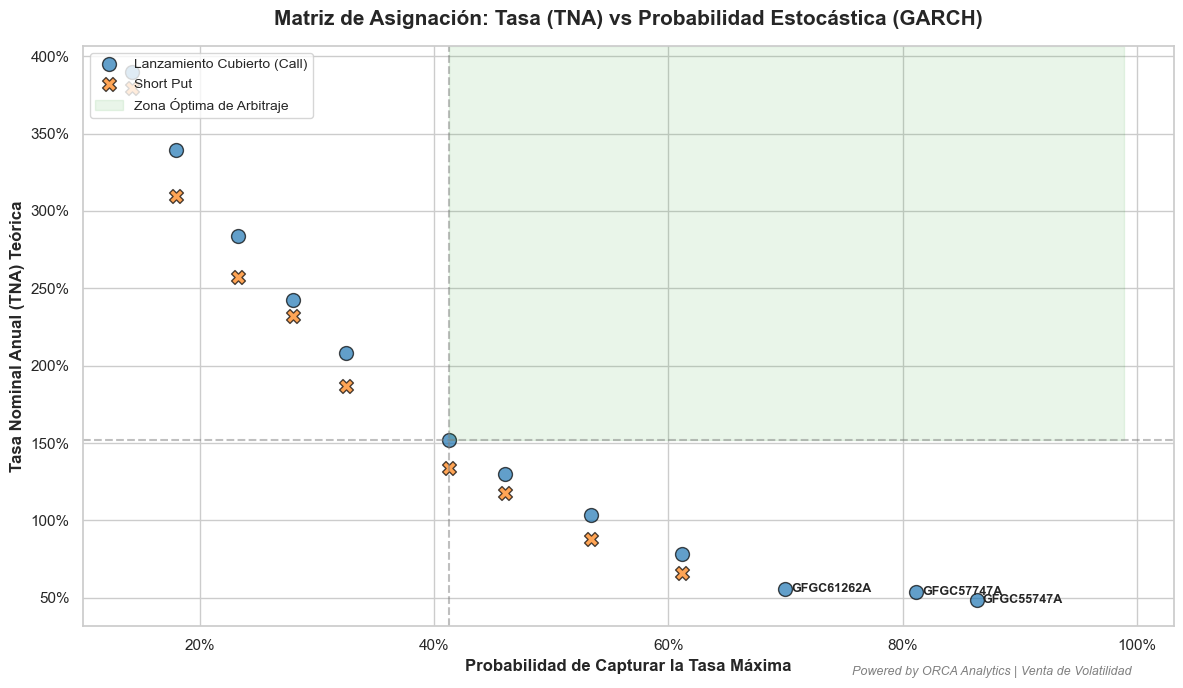

In [94]:
# ======================================================
# BLOQUE · ESTRATEGIAS DE "HACER TASA" Y VENTA DE VOLATILIDAD
# ======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

print("💸 Escaneando mercado para estrategias de generación de Tasa (Lanzamiento / Short Put)...")

estrategias_tasa = []

# Iteramos sobre toda la cadena de opciones del vencimiento seleccionado
for idx, row in df_vto.iterrows():
    tipo = str(row['tipoOpcion']).upper()
    K = row['strike']
    prima = row['mid']
    
    # Filtro básico de liquidez (primas mayores a 0)
    if prima <= 0: continue
        
    if tipo == "CALL":
        # Estrategia: Lanzamiento Cubierto (Covered Call)
        # Compro el papel a 'spot', vendo el Call a 'prima'. 
        # Si al vencimiento Spot >= K, me ejercen y entrego los papeles a K.
        inversion_inicial = spot
        ingreso_maximo = K + prima
        
        # Rendimiento directo si soy ejercido
        rendimiento_directo = (ingreso_maximo / inversion_inicial) - 1
        
        # Probabilidad de éxito (Prob. de ser ejercido y cobrar la tasa máxima)
        # Es decir, la probabilidad según GARCH de que el precio final sea mayor al Strike
        prob_exito = np.mean(precios_finales >= K)
        
        # Cobertura a la baja (Downside protection): Cuánto puede caer el papel sin que pierda plata
        cobertura = prima / spot
        
    else: # PUT
        # Estrategia: Venta de Put Garantizado (Cash Secured Put)
        # Vendo el Put, cobro 'prima'. Inmovilizo (K - prima) de capital.
        # Si al vencimiento Spot >= K, la opción expira sin valor y me quedo la prima.
        inversion_inicial = K - prima
        ingreso_maximo = K
        
        # Rendimiento directo si la opción expira OTM
        rendimiento_directo = prima / inversion_inicial if inversion_inicial > 0 else 0
        
        # Probabilidad de éxito (Prob. de que NO me ejerzan)
        prob_exito = np.mean(precios_finales >= K)
        
        # Cobertura: El break-even es K - prima
        cobertura = (spot - (K - prima)) / spot if spot > (K-prima) else 0

    # Anualizar la tasa (TNA)
    tna = rendimiento_directo * (365 / dias_vto)
    
    estrategias_tasa.append({
        "Simbolo": row['simbolo'],
        "Estrategia": "Lanzamiento Cubierto" if tipo == "CALL" else "Short Put",
        "Strike": K,
        "Prima": prima,
        "TNA_Max": tna,
        "Prob_Exito_GARCH": prob_exito,
        "Cobertura_Caida": cobertura
    })

df_tasa = pd.DataFrame(estrategias_tasa)

# Filtramos opciones demasiado profundas ITM o OTM que ensucian el análisis, 
# y nos quedamos con aquellas que ofrezcan una TNA mayor a la tasa libre de riesgo
df_tasa_filtrada = df_tasa[(df_tasa['TNA_Max'] > cfg['risk_free_rate']) & 
                           (df_tasa['Prob_Exito_GARCH'] > 0.10) & 
                           (df_tasa['Prob_Exito_GARCH'] < 0.95)]

print("\n🏆 Top 5 Oportunidades de Tasa (Mayor Probabilidad Ajustada por GARCH):")
display(
    df_tasa_filtrada.sort_values(["Prob_Exito_GARCH", "TNA_Max"], ascending=[False, False])
    .head(5).style.format({
        "Strike": "${:.2f}",
        "Prima": "${:.2f}",
        "TNA_Max": "{:.2%}",
        "Prob_Exito_GARCH": "{:.2%}",
        "Cobertura_Caida": "{:.2%}"
    }).background_gradient(subset=["TNA_Max", "Prob_Exito_GARCH"], cmap="YlGn")
)

# ------------------------------------------------------
# Dashboard Visual: Matriz TNA vs Probabilidad
# ------------------------------------------------------
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({'font.family': 'sans-serif', 'axes.titleweight': 'bold'})

fig, ax = plt.subplots(figsize=(12, 7))

# Separar para colorear en el gráfico
df_cc = df_tasa_filtrada[df_tasa_filtrada['Estrategia'] == "Lanzamiento Cubierto"]
df_sp = df_tasa_filtrada[df_tasa_filtrada['Estrategia'] == "Short Put"]

# Scatter plot: Eje X (Probabilidad), Eje Y (TNA)
scatter1 = ax.scatter(df_cc['Prob_Exito_GARCH'], df_cc['TNA_Max'], 
                      color='#1f77b4', s=100, alpha=0.7, edgecolor='black', label="Lanzamiento Cubierto (Call)")
scatter2 = ax.scatter(df_sp['Prob_Exito_GARCH'], df_sp['TNA_Max'], 
                      color='#ff7f0e', marker='X', s=100, alpha=0.7, edgecolor='black', label="Short Put")

# Cuadrantes analíticos
tna_media = df_tasa_filtrada['TNA_Max'].median()
prob_media = df_tasa_filtrada['Prob_Exito_GARCH'].median()

ax.axhline(tna_media, color='gray', linestyle='--', alpha=0.5)
ax.axvline(prob_media, color='gray', linestyle='--', alpha=0.5)

# Sombreado del "Sweet Spot" (Alta Tasa + Alta Probabilidad)
ax.axvspan(prob_media, ax.get_xlim()[1]*1.1, ymin=(tna_media - ax.get_ylim()[0])/(ax.get_ylim()[1] - ax.get_ylim()[0]), ymax=1, 
           color='#2ca02c', alpha=0.1, label="Zona Óptima de Arbitraje")

# Etiquetas a los mejores puntos (Arriba a la derecha)
top_estrategias = df_tasa_filtrada.sort_values(by=['Prob_Exito_GARCH', 'TNA_Max'], ascending=False).head(3)
for _, row in top_estrategias.iterrows():
    ax.text(row['Prob_Exito_GARCH'] + 0.005, row['TNA_Max'], row['Simbolo'], 
            fontsize=9, fontweight='bold', ha='left', va='center')

# Formateo del gráfico
ax.set_title("Matriz de Asignación: Tasa (TNA) vs Probabilidad Estocástica (GARCH)", fontsize=15, pad=15)
ax.set_xlabel("Probabilidad de Capturar la Tasa Máxima", fontsize=12)
ax.set_ylabel("Tasa Nominal Anual (TNA) Teórica", fontsize=12)

ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))

ax.legend(loc="upper left", frameon=True, fontsize=10)
fig.text(0.95, 0.02, 'Powered by ORCA Analytics | Venta de Volatilidad', 
         fontsize=9, color='gray', ha='right', va='bottom', style='italic')

plt.tight_layout()
plt.show()